In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_loader
from src.misc import load_config

In [2]:
CONFIG_PATH = ROOT / "config" / "model.yaml"
BATCH_SIZE = 4

In [3]:
args = Namespace(**load_config(CONFIG_PATH))
data_dir = Path(args.data_dir)
args.data_dir = data_dir if data_dir.is_absolute() else ROOT / data_dir
args.batch_size = BATCH_SIZE
args.augment = False

dataset = build_dataset(args)
images, fractions = next(
    build_loader(dataset, args, device=torch.device("cpu"))
)

mean_fractions = [round(value, 4) for value in fractions.mean(dim=0).tolist()]
print(
    f"samples={len(dataset)} batch={tuple(images.shape)} "
    f"fractions={mean_fractions}"
)

samples=2240 batch=(4, 1, 64, 64) fractions=[0.5982, 0.1772, 0.2245]


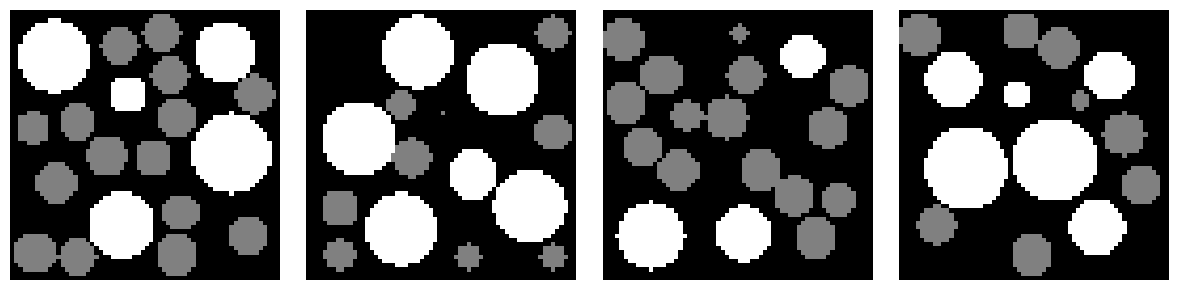

In [4]:
count = min(BATCH_SIZE, images.shape[0])
fig, axes = plt.subplots(1, count, figsize=(3 * count, 3), squeeze=False)
for axis, image in zip(axes.ravel(), images[:count, 0]):
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=args.num_phases - 1,
        interpolation="nearest",
    )
    axis.axis("off")
plt.tight_layout()